## Milestone 2 - Spark EDA [Expanse]

**Dataset:** Provident Vehicle Detection at Night (PVDN)

**Goal:** Data structure Exploration, Counts, missing values, duplicates, label distributions and basic image metadata


In [7]:
# Libraries & Packages
import os
import json
import glob as pyglob
import kagglehub
import pandas as pd
from IPython.display import display, Markdown
from pyspark.sql import (
    SparkSession, functions as F, DataFrame, Window
    )
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, LongType,
    BooleanType, ArrayType, DoubleType
)
from functools import reduce
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Pandas Table Display Wrapper
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

def show(df, n=100):
    """Display a Spark DataFrame as a formatted HTML table (computation stays in Spark)."""
    display(df.limit(n).toPandas())

In [3]:
# Expanse Environment (active)
DATA_ROOT = "/expanse/lustre/projects/uci157/kkravchenko/provident-vehicle-detection-at-night-pvdn"

# Local Environment
# path = kagglehub.dataset_download("saralajew/provident-vehicle-detection-at-night-pvdn")
# DATA_ROOT = path
# os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
# os.environ["PATH"] = "/opt/homebrew/opt/openjdk@17/bin:" + os.environ["PATH"]

OUTPUT_ROOT = os.path.join(DATA_ROOT, "_eda_outputs")
os.makedirs(OUTPUT_ROOT, exist_ok=True)

In [ ]:
# Expanse Environment (active)
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

# Local Environment
# spark = SparkSession.builder \
#     .appName("PVDN Dataset Exploration") \
#     .master("local[*]") \
#     .config("spark.driver.memory", "12g") \
#     .config("spark.executor.memory", "12g") \
#     .config("spark.sql.shuffle.partitions", 10) \
#     .config("spark.default.parallelism", 10) \
#     .config("spark.driver.maxResultSize", "4g") \
#     .config("spark.sql.adaptive.enabled", "true") \
#     .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
#     .config("spark.local.dir", "/tmp/spark-temp") \
#     .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/22 14:51:35 WARN Utils: Your hostname, MacBook-Pro-M4Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.66 instead (on interface en0)
26/02/22 14:51:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/22 14:51:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/22 14:51:35 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


## Load the annotation JSON files into Spark DataFrames

- We read all 6 `image_annotations.json` files in a single `spark.read.json()` call, and likewise for `sequences.json`.

- `time_of_day` and `split` are extracted from the file path via `input_file_name()` rather than Python literals, keeping everything inside the Spark execution plan.

- The resulting `images_df` is a single joined DataFrame containing image metadata, annotation labels, and category names.

In [5]:
base = os.path.join(DATA_ROOT, "PVDN")
ann_paths = sorted(pyglob.glob(os.path.join(base, "*", "*", "labels", "image_annotations.json")))
seq_paths = sorted(pyglob.glob(os.path.join(base, "*", "*", "labels", "sequences.json")))

def add_path_metadata(df, tod_offset, split_offset):
    """Extract time_of_day and split from the file path."""
    return df \
        .withColumn("_parts", F.split(F.input_file_name(), "/")) \
        .withColumn("time_of_day", F.element_at(F.col("_parts"), tod_offset)) \
        .withColumn("split", F.element_at(F.col("_parts"), split_offset)) \
        .drop("_parts")

ann_raw = spark.read.option("multiLine", True).json(ann_paths)

images_raw = add_path_metadata(
    ann_raw.select(F.explode("images").alias("img")).select(
        F.col("img.id").alias("image_id"),
        F.col("img.file_name").alias("file_name"),
        F.col("img.height").alias("height"),
        F.col("img.width").alias("width"),
        F.col("img.timestamp").alias("timestamp"),
        F.col("img.date_captured").alias("date_captured"),
        F.col("img.licence").alias("licence"),
        F.col("img.camera_configuration").alias("camera_configuration"),
    ), tod_offset=-4, split_offset=-3
)

annotations_df = add_path_metadata(
    ann_raw.select(F.explode("annotations").alias("ann")).select(
        F.col("ann.id").alias("annotation_id"),
        F.col("ann.image_id").alias("image_id"),
        F.col("ann.category").alias("category"),
    ), tod_offset=-4, split_offset=-3
)

cat_lookup = ann_raw.select(F.explode("categories").alias("cat")).select(
    F.col("cat.id").alias("category_id"),
    F.col("cat.name").alias("category_name"),
    F.col("cat.supercategory").alias("supercategory"),
).distinct()

seq_raw = spark.read.option("multiLine", True).json(seq_paths)

sequences_df = add_path_metadata(
    seq_raw.select(F.explode("sequences").alias("seq")).select(
        F.col("seq.id").alias("sequence_id"),
        F.col("seq.dir").alias("directory"),
        F.col("seq.start_time").alias("start_time"),
        F.col("seq.end_time").alias("end_time"),
        F.col("seq.num_images").alias("num_images"),
        F.col("seq.image_ids").alias("image_ids"),
        F.col("seq.proband_id").alias("proband_id"),
        F.col("seq.sector").alias("sector"),
        F.col("seq.direction").alias("direction"),
        F.col("seq.street_style").alias("street_style"),
        F.col("seq.dome").alias("dome"),
        F.col("seq.proband_behaviour").alias("proband_behaviour"),
        F.col("seq.road_type").alias("road_type"),
        F.col("seq.view").alias("view"),
        F.col("seq.weather").alias("weather"),
        F.col("seq.environment_lighting").alias("environment_lighting"),
    ), tod_offset=-4, split_offset=-3
)

images_df = images_raw \
    .join(annotations_df, ["image_id", "time_of_day", "split"]) \
    .join(cat_lookup, F.col("category") == cat_lookup["category_id"], "left") \
    .drop("category_id")

images_df.cache()
sequences_df.cache()

print(f"Loaded {images_df.count()} images (with annotations + category names), "
      f"{cat_lookup.count()} distinct categories, "
      f"{sequences_df.count()} sequences")

Loaded 59746 images (with annotations + category names), 8 distinct categories, 346 sequences


## Load keypoint annotation files

Each image has a corresponding `{image_id:06d}.json` file in the `keypoints/` directory with:
- **`image_id`**: the image this annotation belongs to
- **`annotations`**: list of vehicle objects, each containing:
  - `oid` - unique vehicle ID within the image
  - `pos` - keypoint `[x, y]`: centered between headlights (direct) or predicted road appearance point (indirect)
  - `direct` - `True` if the vehicle is directly visible, `False` if only detectable via light reflections
  - `instances` - list of associated light instances, each with `iid`, `pos`, `direct`, `rear`
- **`blurs`**: list of `[x1, y1, x2, y2]` bounding boxes for blurred regions

We use Pandas for the initial read instead of Spark because the keypoint data is split across tens of thousands of small, multi-line JSON files (one per image). Spark's built-in JSON reader is optimized for a few large files or single-line JSONL. When given many tiny multi-line files it consolidates them into a single oversized task, creating a bottleneck that eliminates any parallelism benefit.


In [9]:
kp_dirs = sorted(pyglob.glob(os.path.join(base, "*", "*", "labels", "keypoints")))

vehicle_rows = []
instance_rows = []
blur_rows = []

for kp_dir in kp_dirs:
    parts = kp_dir.replace("\\", "/").split("/")
    time_of_day = parts[-4]
    split = parts[-3]
    for fp in sorted(pyglob.glob(os.path.join(kp_dir, "*.json"))):
        with open(fp) as f:
            rec = json.load(f)
        img_id = rec["image_id"]

        for blur in rec.get("blurs", []):
            blur_rows.append((img_id, time_of_day, split,
                              float(blur[0]), float(blur[1]),
                              float(blur[2]), float(blur[3])))

        for veh in rec.get("annotations", []):
            insts = veh.get("instances", [])
            vehicle_rows.append((img_id, time_of_day, split,
                                 veh["pos"], veh["oid"],
                                 bool(veh["direct"]), len(insts)))
            for inst in insts:
                instance_rows.append((img_id, time_of_day, split,
                                      veh["oid"], bool(veh["direct"]),
                                      inst["pos"], inst["iid"],
                                      bool(inst["direct"]), bool(inst["rear"])))

vehicles_schema = StructType([
    StructField("image_id", LongType()),
    StructField("time_of_day", StringType()),
    StructField("split", StringType()),
    StructField("vehicle_pos", ArrayType(IntegerType())),
    StructField("vehicle_oid", LongType()),
    StructField("vehicle_direct", BooleanType()),
    StructField("num_instances", IntegerType()),
])

instances_schema = StructType([
    StructField("image_id", LongType()),
    StructField("time_of_day", StringType()),
    StructField("split", StringType()),
    StructField("vehicle_oid", LongType()),
    StructField("vehicle_direct", BooleanType()),
    StructField("instance_pos", ArrayType(IntegerType())),
    StructField("instance_id", LongType()),
    StructField("instance_direct", BooleanType()),
    StructField("instance_rear", BooleanType()),
])

blurs_schema = StructType([
    StructField("image_id", LongType()),
    StructField("time_of_day", StringType()),
    StructField("split", StringType()),
    StructField("x1", DoubleType()),
    StructField("y1", DoubleType()),
    StructField("x2", DoubleType()),
    StructField("y2", DoubleType()),
])

vehicles_df = spark.createDataFrame(vehicle_rows, schema=vehicles_schema)
instances_df = spark.createDataFrame(instance_rows, schema=instances_schema)
blurs_df = spark.createDataFrame(blur_rows, schema=blurs_schema)

vehicles_df.cache()
instances_df.cache()
blurs_df.cache()

print("Keypoint DataFrames loaded successfully.")
print(f"  vehicles: {vehicles_df.count()} rows")
print(f"  instances: {instances_df.count()} rows")
print(f"  blurs: {blurs_df.count()} rows")

Keypoint DataFrames loaded successfully.


  vehicles: 54649 rows
  instances: 157835 rows
  blurs: 2418 rows


### **3a**. How many observations does your dataset have?

In [10]:
total_images = images_df.count()
print(f"Total images (observations): {total_images}")

display(Markdown("**Images per time_of_day**"))
show(images_df.groupBy("time_of_day").agg(F.count("*").alias("num_images")))

display(Markdown("**Images per time_of_day × split**"))
show(images_df.groupBy("time_of_day", "split").agg(F.count("*").alias("num_images")).orderBy("time_of_day", "split"))

print(f"\nTotal distinct categories: {images_df.select('category').distinct().count()}")
print(f"Total sequences: {sequences_df.count()}")
print(f"Total vehicle keypoint records: {vehicles_df.count()}")
print(f"Total instance keypoint records: {instances_df.count()}")

Total images (observations): 59746


**Images per time_of_day**

,time_of_day,num_images
0,night,33638
1,day,26108


**Images per time_of_day × split**

,time_of_day,split,num_images
0,day,test,3132
1,day,train,19078
2,day,val,3898
3,night,test,4052
4,night,train,25264
5,night,val,4322



Total distinct categories: 7
Total sequences: 346
Total vehicle keypoint records: 54649
Total instance keypoint records: 157835


### **3b**. Describe all columns in your dataset: their scales and data distributions. Describe categorical and continuous variables. Describe your target column.

#### `images_df` - image metadata + annotation + category columns

In [ ]:
print("Images DataFrame Schema")
images_df.printSchema()

display(Markdown("**Sample Rows**"))
show(images_df, 5)

display(Markdown("**Descriptive Statistics**"))
show(images_df.describe("image_id", "height", "width", "timestamp", "licence", "camera_configuration"))

display(Markdown("**Unique Values Per Column**"))
show(images_df.agg(*[
    F.countDistinct(c).alias(c) for c in ["time_of_day", "split", "licence", "camera_configuration"]
]))

display(Markdown("**Time Of Day x Split Distribution**"))
show(images_df.groupBy("time_of_day", "split").agg(F.count("*").alias("count")).orderBy("time_of_day", "split"))

display(Markdown("**Camera Configuration Distribution**"))
show(images_df.groupBy("camera_configuration").agg(F.count("*").alias("count")).orderBy("camera_configuration"))

display(Markdown("**Image Dimension Distribution**"))
show(images_df.groupBy("height", "width").agg(F.count("*").alias("count")).orderBy(F.desc("count")))

Images DataFrame Schema
root
 |-- image_id: long (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- split: string (nullable = true)
 |-- file_name: string (nullable = true)
 |-- height: long (nullable = true)
 |-- width: long (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- date_captured: string (nullable = true)
 |-- licence: long (nullable = true)
 |-- camera_configuration: long (nullable = true)
 |-- annotation_id: long (nullable = true)
 |-- category: long (nullable = true)
 |-- category_name: string (nullable = true)
 |-- supercategory: string (nullable = true)



**Sample Rows**

,image_id,time_of_day,split,file_name,height,width,timestamp,date_captured,licence,camera_configuration,annotation_id,category,category_name,supercategory
0,1,night,train,000001.png,960,1280,None,2018-01-01 00:00:00,0,0,1,0,no approaching vehicles,label
1,3,night,train,000003.png,960,1280,None,2018-01-01 00:00:00,0,0,3,0,no approaching vehicles,label
2,5,night,train,000005.png,960,1280,None,2018-01-01 00:00:00,0,0,5,0,no approaching vehicles,label
3,7,night,train,000007.png,960,1280,None,2018-01-01 00:00:00,0,0,7,0,no approaching vehicles,label
4,9,night,train,000009.png,960,1280,None,2018-01-01 00:00:00,0,0,9,0,no approaching vehicles,label


**Descriptive Statistics (Numeric)**

26/02/22 14:57:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


...

,time_of_day,split,count
0,day,test,3132
1,day,train,19078
2,day,val,3898
3,night,test,4052
4,night,train,25264
5,night,val,4322


**Camera Configuration Distribution**

,camera_configuration,count
0,0,33638
1,1,26108


**Image Dimension Distribution**

,height,width,count
0,960,1280,59746


##### Annotation columns in `images_df` - category labels per image

Each image has exactly one annotation from `image_annotations.json` assigning it to one of 8 categories (joined into `images_df` during loading).
These categories represent a temporal progression of oncoming vehicle detection:

In [12]:
print("Annotation Columns in images_df")
images_df.select("annotation_id", "category", "category_name", "supercategory").printSchema()

display(Markdown("**Sample Rows**"))
show(images_df.select("image_id", "annotation_id", "category", "category_name", "split"), 5)

display(Markdown("**Category Statistics**"))
show(images_df.describe("category"))

display(Markdown("**Category Distribution (Target)**"))
show(images_df.groupBy("category", "category_name").agg(F.count("*").alias("count")).orderBy("category"))

display(Markdown("**Category Distribution Per Split**"))
show(images_df.groupBy("split", "category", "category_name").agg(
    F.count("*").alias("count")
).orderBy("split", "category"), 50)

Annotation Columns in images_df
root
 |-- annotation_id: long (nullable = true)
 |-- category: long (nullable = true)
 |-- category_name: string (nullable = true)
 |-- supercategory: string (nullable = true)



**Sample Rows**

,image_id,annotation_id,category,category_name,split
0,1,1,0,no approaching vehicles,train
1,3,3,0,no approaching vehicles,train
2,5,5,0,no approaching vehicles,train
3,7,7,0,no approaching vehicles,train
4,9,9,0,no approaching vehicles,train


**Category Statistics**

,summary,category
0,count,59746
1,mean,4.107103404412011
2,stddev,2.6512388851245827
3,min,0
4,max,6


**Category Distribution (Target)**

,category,category_name,count
0,0,no approaching vehicles,15520
1,1,first visible signs for oncoming vehicle,152
2,2,indirect light artifacts of oncoming vehicle,4107
3,3,first direct light artifacts of oncoming vehicle,108
4,4,direct light artifacts of oncoming vehicle,1180
5,5,first direct sight of vehicle,101
6,6,first trigger low beam,38578


**Category Distribution Per Split**

,split,category,category_name,count
0,test,0,no approaching vehicles,1911
1,test,1,first visible signs for oncoming vehicle,21
2,test,2,indirect light artifacts of oncoming vehicle,571
3,test,3,first direct light artifacts of oncoming vehicle,18
4,test,4,direct light artifacts of oncoming vehicle,114
5,test,5,first direct sight of vehicle,15
6,test,6,first trigger low beam,4534
7,train,0,no approaching vehicles,11288
8,train,1,first visible signs for oncoming vehicle,110
9,train,2,indirect light artifacts of oncoming vehicle,2701


##### `cat_lookup` - category class definitions

In [13]:
print("Categories (cat_lookup)")
cat_lookup.printSchema()

show(cat_lookup.orderBy("category_id"))
print(f"\nTotal distinct categories: {cat_lookup.count()}")

Categories (cat_lookup)
root
 |-- category_id: long (nullable = true)
 |-- category_name: string (nullable = true)
 |-- supercategory: string (nullable = true)



,category_id,category_name,supercategory
0,0,no approaching vehicles,label
1,1,first visible signs for oncoming vehicle,event
2,2,indirect light artifacts of oncoming vehicle,label
3,3,first direct light artifacts of oncoming vehicle,event
4,4,direct light artifacts of oncoming vehicle,label
5,5,first direct sight of vehicle,event
6,6,first trigger low beam,event
7,7,low beam,label



Total distinct categories: 8


#### `sequences_df` - scene-level metadata (categorical variables)

##### Each sequence has rich categorical metadata encoded as integer enums.

In [14]:
print("Sequences DataFrame Schema")
sequences_df.printSchema()

display(Markdown("**Sample Rows**"))
show(sequences_df.drop("image_ids"), 5)

display(Markdown("**Continuous Variable Statistics (start_time, end_time, num_images)**"))
show(sequences_df.describe("start_time", "end_time", "num_images"))

categorical_cols = [
    "direction", "street_style", "proband_behaviour",
    "road_type", "view", "weather", "environment_lighting", "dome"
]

stack_expr = ", ".join([f"'{c}', CAST({c} AS STRING)" for c in categorical_cols])
display(Markdown("**Categorical Variable Distributions**"))
show(
    sequences_df
    .selectExpr(f"stack({len(categorical_cols)}, {stack_expr}) AS (column_name, value)")
    .groupBy("column_name", "value")
    .agg(F.count("*").alias("count"))
    .orderBy("column_name", "value")
)

display(Markdown("**Unique Nominal Identifiers**"))
show(sequences_df.agg(*[
    F.countDistinct(c).alias(c) for c in ["sequence_id", "proband_id", "sector"]
]))

display(Markdown("**Sequences Per Split**"))
show(sequences_df.groupBy("split").agg(F.count("*").alias("count")))

Sequences DataFrame Schema
root
 |-- sequence_id: long (nullable = true)
 |-- directory: string (nullable = true)
 |-- start_time: long (nullable = true)
 |-- end_time: long (nullable = true)
 |-- num_images: long (nullable = true)
 |-- image_ids: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- proband_id: long (nullable = true)
 |-- sector: double (nullable = true)
 |-- direction: long (nullable = true)
 |-- street_style: long (nullable = true)
 |-- dome: boolean (nullable = true)
 |-- proband_behaviour: long (nullable = true)
 |-- road_type: long (nullable = true)
 |-- view: long (nullable = true)
 |-- weather: long (nullable = true)
 |-- environment_lighting: long (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- split: string (nullable = true)



**Sample Rows**

,sequence_id,directory,start_time,end_time,num_images,proband_id,sector,direction,street_style,dome,proband_behaviour,road_type,view,weather,environment_lighting,time_of_day,split
0,0,S00000,0,0,313,1,13.0,0,6,True,2,1,1,3,2,night,train
1,1,S00001,0,0,342,1,12.0,0,3,False,1,1,0,3,2,night,train
2,2,S00002,0,0,331,1,9.0,0,4,False,1,1,0,3,2,night,train
3,3,S00003,0,0,321,1,7.0,0,0,False,1,1,0,3,2,night,train
4,4,S00004,0,0,323,1,13.0,1,3,True,0,1,1,3,2,night,train


**Continuous Variable Statistics (start_time, end_time, num_images)**

,summary,start_time,end_time,num_images
0,count,346,346,346
1,mean,0.0,0.0,345.39884393063585
2,stddev,0.0,0.0,70.65550143278017
3,min,0,0,288
4,max,0,0,733


...

,column_name,value,count
0,direction,0,165
1,direction,1,92
2,direction,2,88
3,direction,4,1
4,dome,false,230
5,dome,true,116
6,environment_lighting,1,18
7,environment_lighting,2,328
8,proband_behaviour,0,144
9,proband_behaviour,1,183


**Unique Nominal Identifiers**

,sequence_id,proband_id,sector
0,346,30,13


**Sequences Per Split**

,split,count
0,train,258
1,val,45
2,test,43


#### `vehicles_df` - keypoint-level data

In [15]:
print("Vehicles DataFrame Schema")
vehicles_df.printSchema()

display(Markdown("**Sample Vehicle Rows**"))
show(vehicles_df, 5)

vehicles_with_xy = vehicles_df.select(
    "split",
    "vehicle_direct",
    F.col("vehicle_pos").getItem(0).alias("vehicle_x"),
    F.col("vehicle_pos").getItem(1).alias("vehicle_y"),
    "num_instances",
)

display(Markdown("**Vehicle Position & Instance Count Statistics**"))
show(vehicles_with_xy.describe("vehicle_x", "vehicle_y", "num_instances"))

display(Markdown("**Vehicle Direct/Indirect Distribution**"))
show(vehicles_df.groupBy("vehicle_direct").agg(F.count("*").alias("count")))

vehicles_per_file = vehicles_df.groupBy("image_id").agg(
    F.count("*").alias("num_vehicles")
)

display(Markdown("**Vehicles Per Image - Statistics**"))
show(vehicles_per_file.describe("num_vehicles"))

display(Markdown("**Vehicles Per Image - Distribution**"))
show(vehicles_per_file.groupBy("num_vehicles").agg(
    F.count("*").alias("num_images")
).orderBy("num_vehicles"), 20)

Vehicles DataFrame Schema
root
 |-- image_id: long (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- split: string (nullable = true)
 |-- vehicle_pos: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- vehicle_oid: long (nullable = true)
 |-- vehicle_direct: boolean (nullable = true)
 |-- num_instances: integer (nullable = true)



**Sample Vehicle Rows**

,image_id,time_of_day,split,vehicle_pos,vehicle_oid,vehicle_direct,num_instances
0,8481,day,test,"[683, 554]",0,False,1
1,8483,day,test,"[683, 553]",0,False,2
2,8485,day,test,"[683, 552]",0,False,2
3,8487,day,test,"[683, 552]",0,False,2
4,8489,day,test,"[677, 557]",0,False,2


**Vehicle Position & Instance Count Statistics**

,summary,vehicle_x,vehicle_y,num_instances
0,count,54649,54649,54649
1,mean,623.2830426906256,527.8972533806657,2.8881589782063717
2,stddev,207.08503622689977,44.147215676484365,1.7397062609247949
3,min,0,233,0
4,max,1278,921,17


...

,vehicle_direct,count
0,False,27677
1,True,26972


**Vehicles Per Image - Statistics**

,summary,num_vehicles
0,count,40480
1,mean,1.3500247035573123
2,stddev,0.8356288940024312
3,min,1
4,max,9


**Vehicles Per Image - Distribution**

,num_vehicles,num_images
0,1,31494
1,2,6152
2,3,1650
3,4,584
4,5,258
5,6,161
6,7,140
7,8,40
8,9,1


#### `instances_df` - keypoint level data

In [16]:
print("Instances DataFrame Schema")
instances_df.printSchema()

display(Markdown("**Sample Instance Rows**"))
show(instances_df, 5)

instances_with_xy = instances_df.select(
    "split",
    "instance_direct",
    "instance_rear",
    F.col("instance_pos").getItem(0).alias("instance_x"),
    F.col("instance_pos").getItem(1).alias("instance_y"),
)

display(Markdown("**Instance Position Statistics**"))
show(instances_with_xy.describe("instance_x", "instance_y"))

display(Markdown("**Instance Direct/Indirect Distribution**"))
show(instances_df.groupBy("instance_direct").agg(F.count("*").alias("count")))

display(Markdown("**Instance Rear Flag Distribution**"))
show(instances_df.groupBy("instance_rear").agg(F.count("*").alias("count")))

inst_per_vehicle = instances_df.groupBy("image_id", "vehicle_oid").agg(
    F.count("*").alias("num_instances")
)

display(Markdown("**Instances Per Vehicle - Statistics**"))
show(inst_per_vehicle.describe("num_instances"))

Instances DataFrame Schema
root
 |-- image_id: long (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- split: string (nullable = true)
 |-- vehicle_oid: long (nullable = true)
 |-- vehicle_direct: boolean (nullable = true)
 |-- instance_pos: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- instance_id: long (nullable = true)
 |-- instance_direct: boolean (nullable = true)
 |-- instance_rear: boolean (nullable = true)



**Sample Instance Rows**

,image_id,time_of_day,split,vehicle_oid,vehicle_direct,instance_pos,instance_id,instance_direct,instance_rear
0,8481,day,test,0,False,"[691, 553]",0,False,False
1,8483,day,test,0,False,"[691, 551]",0,False,False
2,8483,day,test,0,False,"[675, 551]",1,False,False
3,8485,day,test,0,False,"[691, 551]",0,True,False
4,8485,day,test,0,False,"[674, 551]",1,False,False


**Instance Position Statistics**

,summary,instance_x,instance_y
0,count,157835,157835
1,mean,646.6559381632718,519.4892324262679
2,stddev,246.70824718187973,47.21855169773228
3,min,1,59
4,max,1278,952


...

,instance_direct,count
0,False,67755
1,True,90080


**Instance Rear Flag Distribution**

,instance_rear,count
0,False,151190
1,True,6645


**Instances Per Vehicle - Statistics**

,summary,num_instances
0,count,54608
1,mean,2.890327424553179
2,stddev,1.7385576358703587
3,min,1
4,max,17


#### `blurs_df` - keypoint level data

In [17]:
print("Blurs DataFrame Schema")
blurs_df.printSchema()

print(f"\nTotal blur regions: {blurs_df.count()}")

display(Markdown("**Sample Blur Rows**"))
show(blurs_df, 5)

blurs_with_size = blurs_df.select(
    "image_id",
    (F.col("x2") - F.col("x1")).alias("blur_width"),
    (F.col("y2") - F.col("y1")).alias("blur_height"),
)

display(Markdown("**Blur Bounding Box Size Statistics**"))
show(blurs_with_size.describe("blur_width", "blur_height"))

blurs_per_image = blurs_df.groupBy("image_id").agg(F.count("*").alias("num_blurs"))

display(Markdown("**Blurs Per Image**"))
show(blurs_per_image.describe("num_blurs"))

images_with_blurs = blurs_df.select("image_id").distinct().count()
print(f"Images with at least one blur region: {images_with_blurs}")

Blurs DataFrame Schema
root
 |-- image_id: long (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- split: string (nullable = true)
 |-- x1: double (nullable = true)
 |-- y1: double (nullable = true)
 |-- x2: double (nullable = true)
 |-- y2: double (nullable = true)


Total blur regions: 2418


**Sample Blur Rows**

,image_id,time_of_day,split,x1,y1,x2,y2
0,8573,day,test,527.0,563.0,543.0,567.0
1,8575,day,test,521.0,562.0,538.0,565.0
2,8577,day,test,516.0,560.0,533.0,564.0
3,8579,day,test,509.0,559.0,527.0,563.0
4,8581,day,test,506.0,559.0,521.0,562.0


**Blur Bounding Box Size Statistics**

,summary,blur_width,blur_height
0,count,2418,2418
1,mean,46.21670802315963,17.255169561621173
2,stddev,23.694358159781377,26.957555325957127
3,min,0.0,0.0
4,max,244.0,439.0


**Blurs Per Image**

,summary,num_blurs
0,count,2175
1,mean,1.1117241379310345
2,stddev,0.39885475107809704
3,min,1
4,max,4


Images with at least one blur region: 2175


#### Target Columns:
- `category` (Integer) - temporal stage of vehicle detection, the image-level classification target
- `vehicle_direct` (Boolean) - whether the vehicle is directly visible or only inferred from reflections
- `instance_direct` (Boolean) - whether the light instance is direct (headlamp) or indirect (reflection)
- `instance_rear` (Boolean) - whether the light belongs to a same-direction vehicle (rear lights) vs oncoming

In [18]:
total = images_df.count()

display(Markdown("**Target Class Imbalance Analysis**"))
cat_imbalance = images_df.groupBy("category", "category_name").agg(
    F.count("*").alias("count"),
    F.round(F.count("*") / F.lit(total) * 100, 2).alias("pct"),
).orderBy(F.desc("count"))
show(cat_imbalance)

max_count = cat_imbalance.agg(F.max("count")).first()[0]
min_count = cat_imbalance.agg(F.min("count")).first()[0]
print(f"Imbalance ratio (largest / smallest class): {max_count / min_count:.1f}x")
print(f"Majority class ('first trigger low beam') represents {max_count / total * 100:.1f}% of images")

display(Markdown("**Direct/Indirect Vehicle Visibility Per Image**"))
show(vehicles_df.groupBy("image_id").agg(
    F.sum(F.when(F.col("vehicle_direct"), 1).otherwise(0)).alias("direct_vehicles"),
    F.sum(F.when(~F.col("vehicle_direct"), 1).otherwise(0)).alias("indirect_vehicles"),
    F.count("*").alias("total_vehicles"),
).describe("direct_vehicles", "indirect_vehicles", "total_vehicles"))

**Target Class Imbalance Analysis**

,category,category_name,count,pct
0,6,first trigger low beam,38578,64.57
1,0,no approaching vehicles,15520,25.98
2,2,indirect light artifacts of oncoming vehicle,4107,6.87
3,4,direct light artifacts of oncoming vehicle,1180,1.98
4,1,first visible signs for oncoming vehicle,152,0.25
5,3,first direct light artifacts of oncoming vehicle,108,0.18
6,5,first direct sight of vehicle,101,0.17


Imbalance ratio (largest / smallest class): 382.0x
Majority class ('first trigger low beam') represents 64.6% of images


**Direct/Indirect Vehicle Visibility Per Image**

,summary,direct_vehicles,indirect_vehicles,total_vehicles
0,count,40480,40480,40480
1,mean,0.6663043478260869,0.6837203557312252,1.3500247035573123
2,stddev,0.6814325956624435,0.8460321754046229,0.8356288940024312
3,min,0,0,1
4,max,6,8,9


### **3c**. Do you have missing and duplicate values in your dataset?

In [41]:

def missing_summary(df, df_name: str):
    total = df.count()

    exprs = []
    for c, t in df.dtypes:
        col = F.col(c)
        is_missing = col.isNull()

        if t in ("double", "float"):
            is_missing = is_missing | F.isnan(col)
        exprs.append(F.sum(F.when(is_missing, 1).otherwise(0)).alias(c))
    miss_counts = df.agg(*exprs)

    long_df = reduce(
        lambda a, b: a.unionByName(b),
        [
            miss_counts.select(
                F.lit(c).alias("column"),
                F.col(c).cast("long").alias("missing_count"),
                F.round((F.col(c) / F.lit(total)) * 100, 4).alias("missing_pct"),
            )
            for c in miss_counts.columns
        ],
    ).orderBy(F.desc("missing_count"))

    display(Markdown(f"**Missing Summary: {df_name} (rows={total:,})**"))
    return long_df

show(missing_summary(images_df, "images_df"), 50)
show(missing_summary(sequences_df, "sequences_df"), 50)
show(missing_summary(vehicles_df, "vehicles_df"), 50)
show(missing_summary(instances_df, "instances_df"), 50)
show(missing_summary(blurs_df, "blurs_df"), 50)

**Missing Summary: images_df (rows=59,746)**

,column,missing_count,missing_pct
0,timestamp,58982,98.7213
1,image_id,0,0.0000
2,time_of_day,0,0.0000
3,split,0,0.0000
4,file_name,0,0.0000
5,height,0,0.0000
6,width,0,0.0000
7,date_captured,0,0.0000
8,licence,0,0.0000
9,camera_configuration,0,0.0000


**Missing Summary: sequences_df (rows=346)**

,column,missing_count,missing_pct
0,sequence_id,0,0.0
1,directory,0,0.0
2,start_time,0,0.0
3,end_time,0,0.0
4,num_images,0,0.0
5,image_ids,0,0.0
6,proband_id,0,0.0
7,sector,0,0.0
8,direction,0,0.0
9,street_style,0,0.0


**Missing Summary: vehicles_df (rows=54,649)**

,column,missing_count,missing_pct
0,image_id,0,0.0
1,time_of_day,0,0.0
2,split,0,0.0
3,vehicle_pos,0,0.0
4,vehicle_oid,0,0.0
5,vehicle_direct,0,0.0
6,num_instances,0,0.0


**Missing Summary: instances_df (rows=157,835)**

,column,missing_count,missing_pct
0,image_id,0,0.0
1,time_of_day,0,0.0
2,split,0,0.0
3,vehicle_oid,0,0.0
4,vehicle_direct,0,0.0
5,instance_pos,0,0.0
6,instance_id,0,0.0
7,instance_direct,0,0.0
8,instance_rear,0,0.0


**Missing Summary: blurs_df (rows=2,418)**

,column,missing_count,missing_pct
0,image_id,0,0.0
1,time_of_day,0,0.0
2,split,0,0.0
3,x1,0,0.0
4,y1,0,0.0
5,x2,0,0.0
6,y2,0,0.0


In [42]:
def duplicate_summary(df, df_name: str, key_cols=None):
    total = df.count()
    distinct_rows = df.dropDuplicates().count()
    dup_rows = total - distinct_rows

    display(Markdown(f"**Duplicate Summary: {df_name}**"))
    print(f"Total rows: {total:,}")
    print(f"Distinct rows: {distinct_rows:,}")
    print(f"Duplicate rows (exact row duplicates): {dup_rows:,}")

    if key_cols:
        distinct_keys = df.select(*key_cols).dropDuplicates().count()
        dup_key_rows = total - distinct_keys
        print(f"Distinct keys ({key_cols}): {distinct_keys:,}")
        print(f"Duplicate key rows (same key repeated): {dup_key_rows:,}")

        print("\nExample duplicated keys:")
        show(
            df.groupBy(*key_cols)
              .agg(F.count("*").alias("n"))
              .filter(F.col("n") > 1)
              .orderBy(F.desc("n")),
            10
        )
duplicate_summary(images_df, "images_df", key_cols=["image_id", "time_of_day", "split"])
duplicate_summary(sequences_df, "sequences_df", key_cols=["sequence_id", "time_of_day", "split"])
duplicate_summary(vehicles_df, "vehicles_df", key_cols=["image_id", "time_of_day", "split", "vehicle_oid"])
duplicate_summary(instances_df, "instances_df", key_cols=["image_id", "time_of_day", "split", "vehicle_oid", "instance_id"])
duplicate_summary(blurs_df, "blurs_df")

**Duplicate Summary: images_df**

Total rows: 59,746
Distinct rows: 59,746
Duplicate rows (exact row duplicates): 0
Distinct keys (['image_id', 'time_of_day', 'split']): 59,746
Duplicate key rows (same key repeated): 0

Example duplicated keys:


,image_id,time_of_day,split,n


**Duplicate Summary: sequences_df**

Total rows: 346
Distinct rows: 346
Duplicate rows (exact row duplicates): 0
Distinct keys (['sequence_id', 'time_of_day', 'split']): 346
Duplicate key rows (same key repeated): 0

Example duplicated keys:


...

**Duplicate Summary: instances_df**

Total rows: 157,835
Distinct rows: 157,835
Duplicate rows (exact row duplicates): 0
Distinct keys (['image_id', 'time_of_day', 'split', 'vehicle_oid', 'instance_id']): 157,814
Duplicate key rows (same key repeated): 21

Example duplicated keys:


,image_id,time_of_day,split,vehicle_oid,instance_id,n
0,25877,day,train,0,1,2
1,25891,day,train,0,1,2
2,25867,day,train,0,1,2
3,25873,day,train,0,1,2
4,25887,day,train,0,1,2
5,25871,day,train,0,1,2
6,25885,day,train,0,1,2
7,25895,day,train,0,1,2
8,25899,day,train,0,1,2
9,25879,day,train,0,1,2


**Duplicate Summary: blurs_df**

Total rows: 2,418
Distinct rows: 2,418
Duplicate rows (exact row duplicates): 0


### **3d**. For image data: describe number of classes, image sizes, uniformity, cropping/normalization needs.

### Cropping / normalization needs (interpretation)

- **Number of classes:** 8 image-level categories (from COCO-style `categories`).
- **Image sizes:** We compute min/mean/max height/width and the most common `(height,width)` pair.
- **Uniformity:** If the most common size accounts for the vast majority of images (e.g., >95%), resizing can be a simple fixed resize. If there are many size pairs, we should standardize sizes via resizing + padding (letterboxing) to preserve aspect ratio.
- **Cropping:** For vehicle detection at night, cropping is not recommended during baseline EDA because important context (glare/reflections) may be near edges. Prefer resize/pad over aggressive cropping.
- **Normalization:** Apply per-channel scaling to `[0,1]` (or mean/std normalization if training a CNN). Also verify color channels (RGB vs grayscale) before final preprocessing.

In [43]:
num_classes = cat_lookup.count()
print(f"Number of classes (categories): {num_classes}")

display(Markdown("**Class list (id → name)**"))
show(cat_lookup.orderBy("category_id"), 50)

Number of classes (categories): 8


**Class list (id → name)**

,category_id,category_name,supercategory
0,0,no approaching vehicles,label
1,1,first visible signs for oncoming vehicle,event
2,2,indirect light artifacts of oncoming vehicle,label
3,3,first direct light artifacts of oncoming vehicle,event
4,4,direct light artifacts of oncoming vehicle,label
5,5,first direct sight of vehicle,event
6,6,first trigger low beam,event
7,7,low beam,label


In [44]:
display(Markdown("**Image sizes: summary statistics**"))
show(images_df.select(
    F.col("height").cast("double").alias("height"),
    F.col("width").cast("double").alias("width"),
).describe(), 50)
sizes_df = images_df.select(
    "image_id", "time_of_day", "split",
    F.col("height").cast("int").alias("height"),
    F.col("width").cast("int").alias("width"),
    (F.col("width") / F.col("height")).alias("aspect_ratio")
)
display(Markdown("**Aspect ratio statistics**"))
show(sizes_df.select("aspect_ratio").describe(), 50)

unique_sizes = sizes_df.select("height", "width").dropDuplicates().count()
print(f"Unique (height,width) pairs: {unique_sizes}")

**Image sizes: summary statistics**

,summary,height,width
0,count,59746,59746
1,mean,960.0,1280.0
2,stddev,0.0,0.0
3,min,960.0,1280.0
4,max,960.0,1280.0


**Aspect ratio statistics**

,summary,aspect_ratio
0,count,59746
1,mean,1.3333333333330704
2,stddev,0.0
3,min,1.3333333333333333
4,max,1.3333333333333333


Unique (height,width) pairs: 1


In [39]:
display(Markdown("**Uniformity of image sizes**"))

size_counts = (sizes_df.groupBy("height", "width")
               .agg(F.count("*").alias("count"))
               .orderBy(F.desc("count")))

show(size_counts, 20)
mode_row = size_counts.first()
mode_h, mode_w, mode_count = mode_row["height"], mode_row["width"], mode_row["count"]
total_images = sizes_df.count()

print(f"Most common size: {mode_w}x{mode_h}  (count={mode_count:,}, pct={mode_count/total_images*100:.2f}%)")
non_mode = total_images - mode_count
print(f"Non-mode images: {non_mode:,}  ({non_mode/total_images*100:.2f}%)")

**Uniformity of image sizes**

,height,width,count
0,960,1280,59746


Most common size: 1280x960  (count=59,746, pct=100.00%)
Non-mode images: 0  (0.00%)


### **4a**. Create visualizations using Spark aggregations + matplotlib/plotly (sample data for plotting if needed)

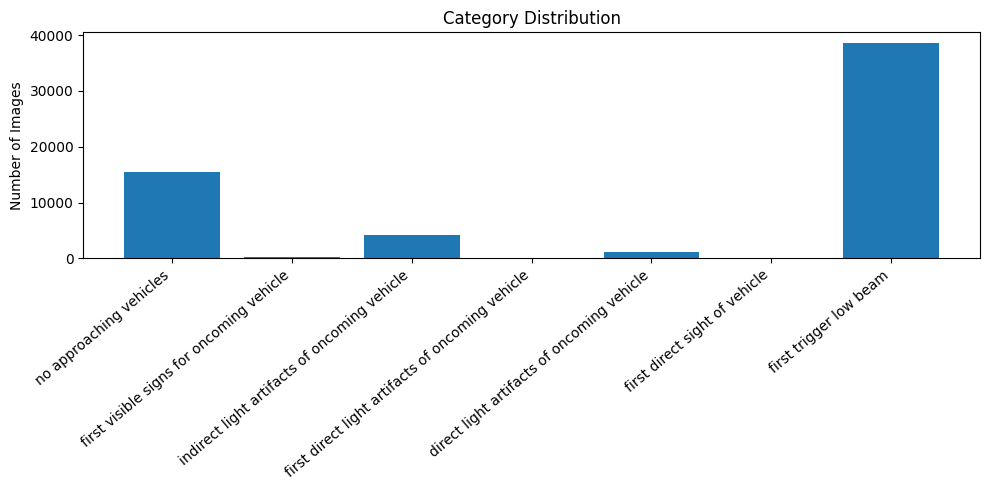

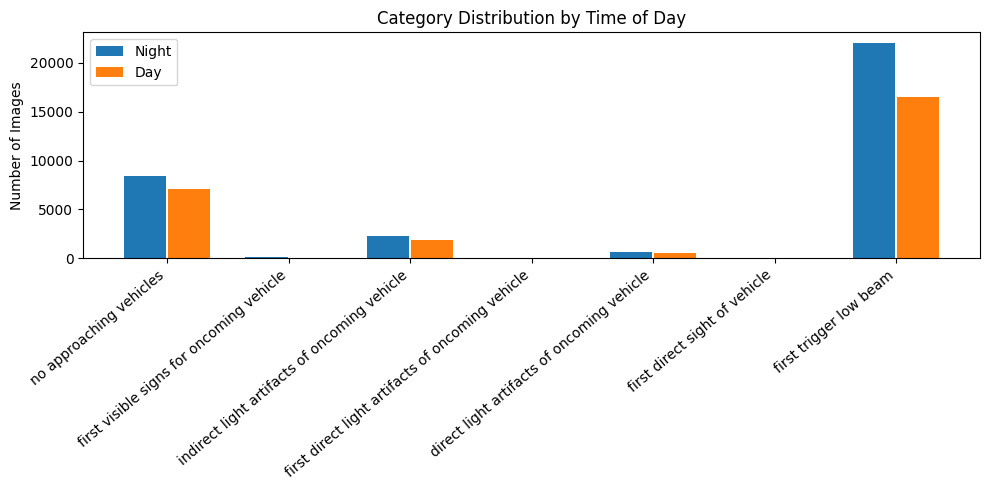

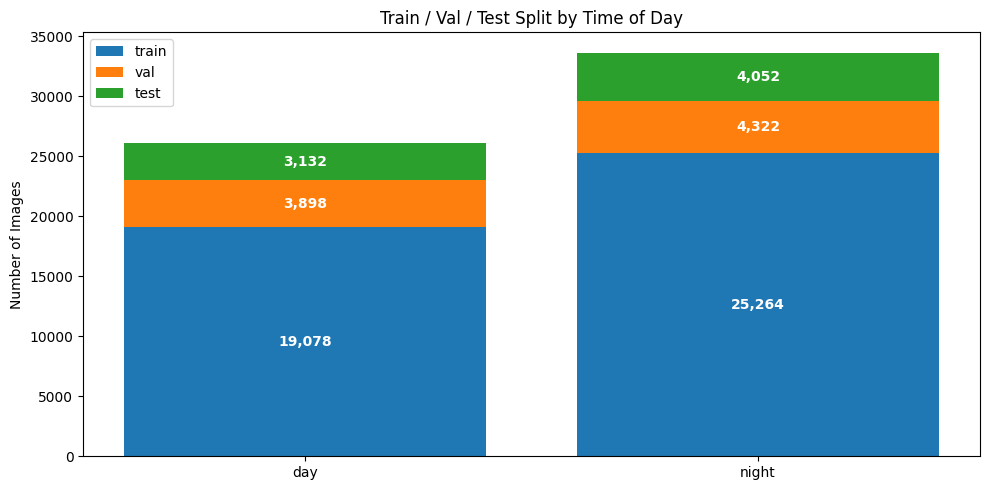

In [45]:
import numpy as np

cat_dist = (
    images_df
    .groupBy("category", "category_name")
    .agg(F.count("*").alias("count"))
    .orderBy("category")
    .collect()
)

labels = [r["category_name"] for r in cat_dist]
counts = [r["count"] for r in cat_dist]

plt.figure(figsize=(10, 5))
plt.bar(labels, counts)
plt.xticks(rotation=40, ha="right")
plt.ylabel("Number of Images")
plt.title("Category Distribution")
plt.tight_layout()
plt.show()

cat_tod = (
    images_df
    .groupBy("time_of_day", "category", "category_name")
    .agg(F.count("*").alias("count"))
    .orderBy("category", "time_of_day")
    .collect()
)

night = [r["count"] for r in cat_tod if r["time_of_day"] == "night"]
day = [r["count"] for r in cat_tod if r["time_of_day"] == "day"]
x = np.arange(len(labels))

plt.figure(figsize=(10, 5))
plt.bar(x - 0.18, night, 0.35, label="Night")
plt.bar(x + 0.18, day, 0.35, label="Day")
plt.xticks(x, labels, rotation=40, ha="right")
plt.ylabel("Number of Images")
plt.title("Category Distribution by Time of Day")
plt.legend()
plt.tight_layout()
plt.show()

split_counts = (
    images_df
    .groupBy("time_of_day", "split")
    .agg(F.count("*").alias("num_images"))
    .orderBy("time_of_day", "split")
    .collect()
)

tod_labels = ["day", "night"]
splits = ["train", "val", "test"]
data = {}
for s in splits:
    data[s] = [next(r["num_images"] for r in split_counts
                    if r["time_of_day"] == t and r["split"] == s)
               for t in tod_labels]

plt.figure(figsize=(10, 5))
bottom = np.zeros(2)
for s in splits:
    plt.bar(tod_labels, data[s], bottom=bottom, label=s)
    for i, v in enumerate(data[s]):
        plt.text(i, bottom[i] + v / 2, f"{v:,}",
                 ha="center", va="center", color="white", fontweight="bold")
    bottom += np.array(data[s])
plt.ylabel("Number of Images")
plt.title("Train / Val / Test Split by Time of Day")
plt.legend()
plt.tight_layout()
plt.show()

### **4b**. Plot your data with various chart types: bar charts, histograms, scatter plots, etc

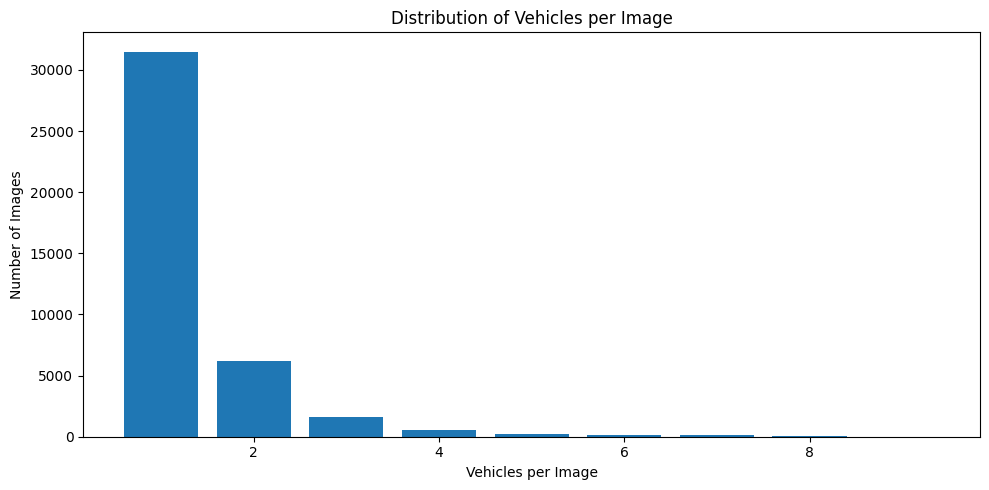

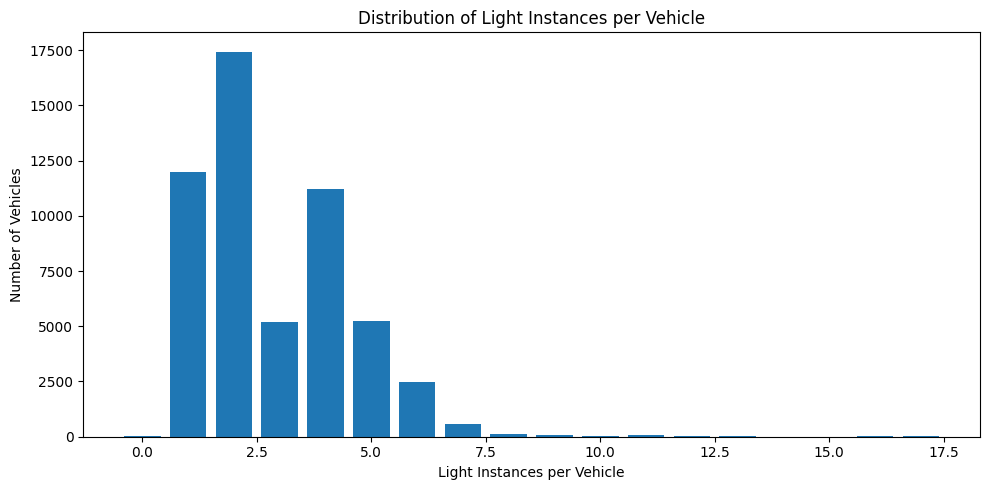

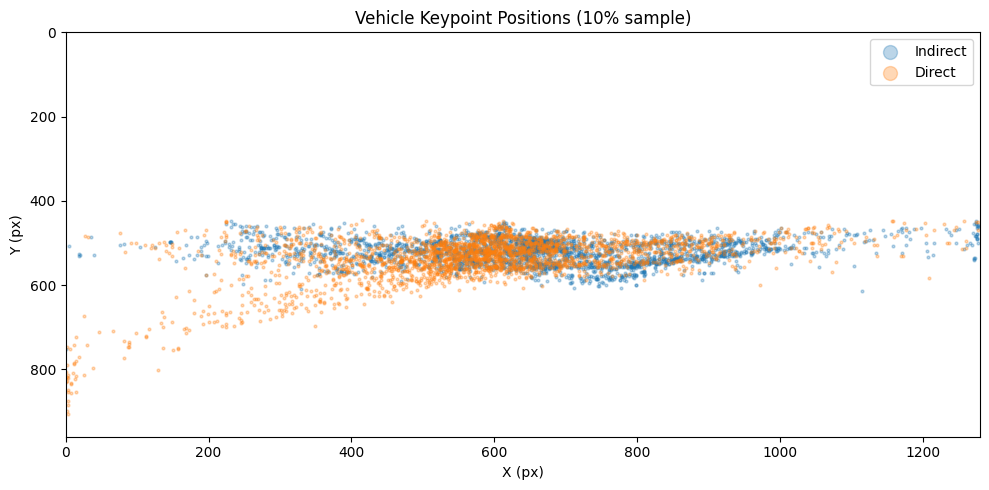

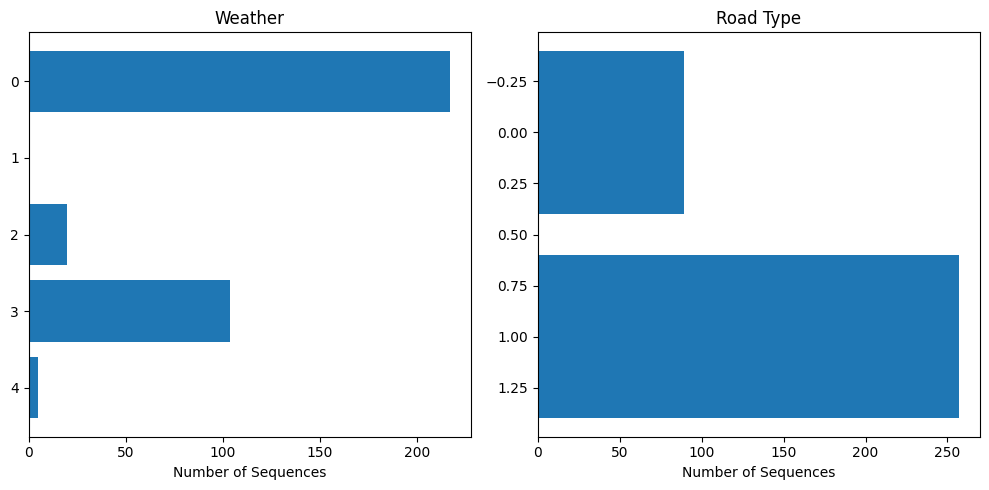

In [46]:
veh_per_img = (
    vehicles_df
    .groupBy("image_id")
    .agg(F.count("*").alias("num_vehicles"))
    .groupBy("num_vehicles")
    .agg(F.count("*").alias("num_images"))
    .orderBy("num_vehicles")
    .collect()
)

plt.figure(figsize=(10, 5))
plt.bar([r["num_vehicles"] for r in veh_per_img],
        [r["num_images"] for r in veh_per_img])
plt.xlabel("Vehicles per Image")
plt.ylabel("Number of Images")
plt.title("Distribution of Vehicles per Image")
plt.tight_layout()
plt.show()

inst_bins = (
    vehicles_df
    .groupBy("num_instances")
    .agg(F.count("*").alias("num_vehicles"))
    .orderBy("num_instances")
    .collect()
)

plt.figure(figsize=(10, 5))
plt.bar([r["num_instances"] for r in inst_bins],
        [r["num_vehicles"] for r in inst_bins])
plt.xlabel("Light Instances per Vehicle")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Light Instances per Vehicle")
plt.tight_layout()
plt.show()

sample = (
    vehicles_df
    .select(
        F.col("vehicle_pos").getItem(0).alias("x"),
        F.col("vehicle_pos").getItem(1).alias("y"),
        "vehicle_direct",
    )
    .filter(F.col("x").isNotNull() & F.col("y").isNotNull())
    .sample(fraction=0.1, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 5))
for label, group in sample.groupby("vehicle_direct"):
    name = "Direct" if label else "Indirect"
    plt.scatter(group["x"], group["y"], s=4, alpha=0.3, label=name)
plt.xlim(0, 1280)
plt.ylim(960, 0)
plt.xlabel("X (px)")
plt.ylabel("Y (px)")
plt.title("Vehicle Keypoint Positions (10% sample)")
plt.legend(markerscale=5)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, col in enumerate(["weather", "road_type"]):
    rows = (
        sequences_df
        .groupBy(col).agg(F.count("*").alias("count"))
        .orderBy(F.desc("count"))
        .collect()
    )
    axes[i].barh([r[col] for r in rows], [r["count"] for r in rows])
    axes[i].set_xlabel("Number of Sequences")
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()

### **4c**. Clearly explain each plot and what insights it provides

#### Plot Explanations

**Category Distribution** - Shows a strong class imbalance. "First trigger low beam" has ~38k images while transition categories like "first visible signs" and "first direct sight" have fewer than 200 each. This will require class weighting or oversampling during training.

**Category Distribution by Time of Day** - Night and day images fall into different categories, confirming that the dataset treats them as separate detection regimes. Models may need separate evaluation per condition.

**Train / Val / Test Split** - The ~74/13/13% split ratio is consistent across day and night, so val/test performance should be comparable between conditions.

**Vehicles per Image** - Most images have 0-2 vehicles with a long tail. Many images have none at all (the "no approaching vehicles" class), so the model needs to handle empty scenes well.

**Light Instances per Vehicle** - Most vehicles have 1-4 light instances but some have 10+. Distant vehicles tend to produce fewer, fainter reflections while close ones generate many bright sources.

**Vehicle Keypoint Positions** - Direct vehicles cluster near the horizon (upper-center), while indirect detections spread across the lower road surface. The y-coordinate alone is a strong signal for distinguishing the two.

**Sequence Metadata (Weather, Road Type)** - Shows the spread of environmental conditions across sequences. This helps gauge whether a model trained on this data will generalize across different weather and road settings.

### **4d**. For image data: plot example classes

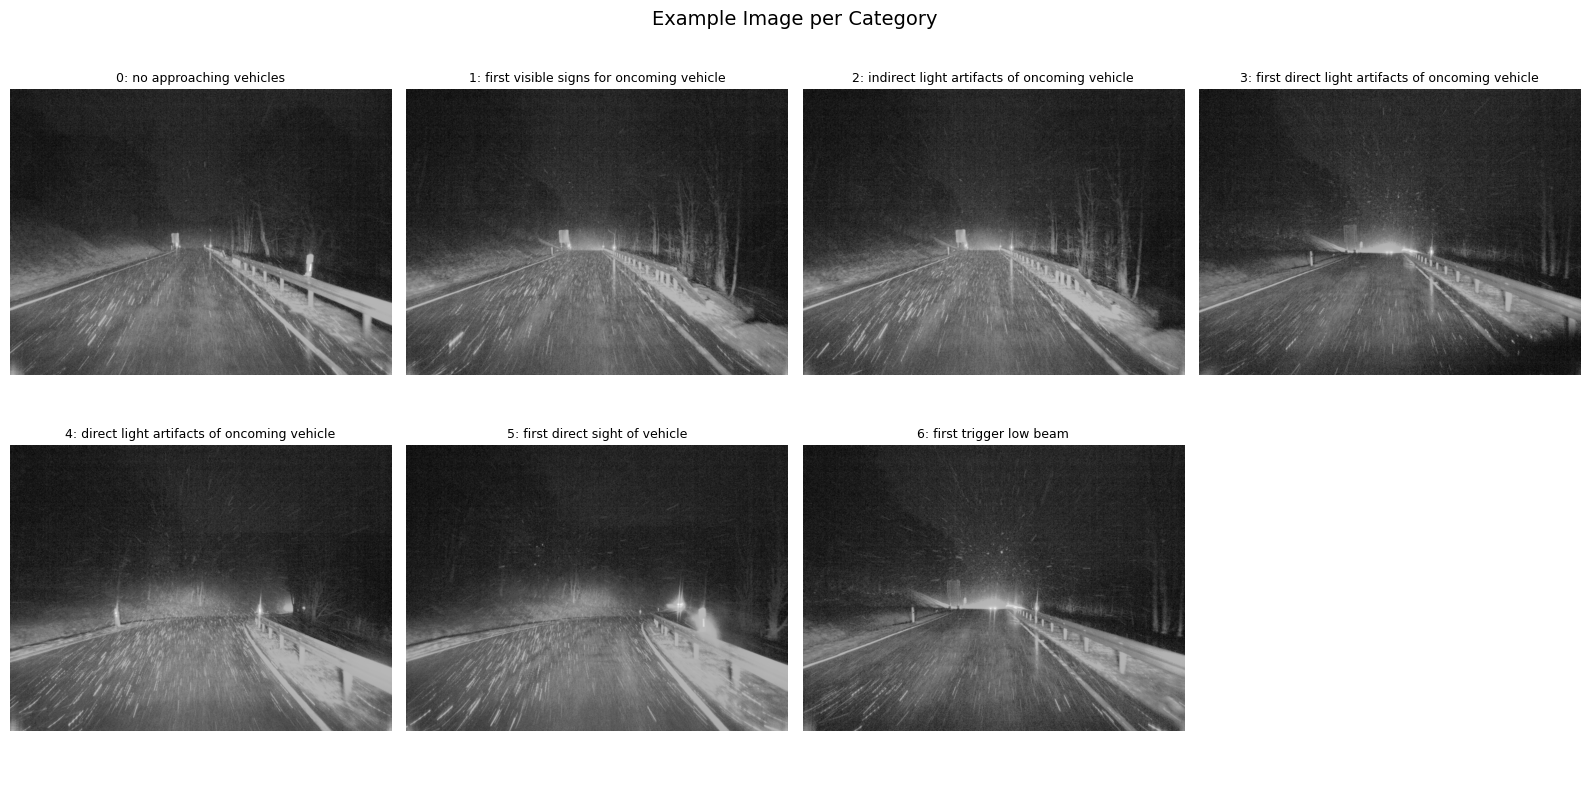

In [47]:
seq_exploded = sequences_df.select(
    "time_of_day", "split", "directory",
    F.explode("image_ids").alias("image_id"),
)

images_with_dir = images_df.join(
    seq_exploded, ["image_id", "time_of_day", "split"], "inner"
)

categories = (
    images_with_dir
    .select("category", "category_name")
    .distinct()
    .orderBy("category")
    .collect()
)

n = len(categories)
cols = min(n, 4)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for i, row in enumerate(categories):
    sample = (
        images_with_dir
        .filter(F.col("category") == row["category"])
        .filter(F.col("directory").isNotNull())
        .select("time_of_day", "split", "directory", "file_name")
        .limit(1)
        .first()
    )
    path = os.path.join(
        DATA_ROOT, "PVDN",
        sample["time_of_day"], sample["split"],
        "images", sample["directory"], sample["file_name"],
    )
    axes[i].imshow(Image.open(path), cmap="gray")
    axes[i].set_title(f"{row['category']}: {row['category_name']}", fontsize=9)
    axes[i].axis("off")

for i in range(n, len(axes)):
    axes[i].axis("off")

fig.suptitle("Example Image per Category", fontsize=14)
plt.tight_layout()
plt.show()

### **5**. Preprocessing Plan for the PVDN dataset.

### Handling Missing Values

Based on the EDA analysis:

- Image metadata fields (height, width, file_name) are expected to be complete.  
- Annotation-related fields (vehicle_oid, instance_id, blur_level, etc.) may contain nulls due to labeling structure.

Planned strategy:

- Drop rows where critical identifiers are missing:
  - `image_id`
  - `annotation_id`
  - `category`
- For optional metadata:
  - Null blur levels will be encoded as a separate category (`"unknown"`).
  - Missing numeric values (if any) will be handled using Spark `fillna()`.

We avoid imputing bounding box or image dimensions since artificial values could bias detection results.

---

### Handling Data Imbalance

The dataset shows imbalance between vehicle categories and environmental conditions.

Planned strategy:

- Analyze class distribution using Spark `groupBy().count()`.
- Use **class-weighted sampling** rather than naive oversampling to avoid overfitting.
- If necessary, apply:
  - stratified sampling by category
  - weighted loss functions during model training (future milestone).

No synthetic data generation will be performed at this stage.

---

### Planned Transformations

Because this is an image-based dataset, preprocessing will focus on image normalization and structural consistency:

1. **Resizing / Padding**
   - Standardize image dimensions to a fixed resolution while preserving aspect ratio.
   - Use letterboxing instead of aggressive cropping to retain nighttime context.

2. **Normalization**
   - Convert pixel values from `[0,255]` to `[0,1]`.
   - Optional mean/std normalization depending on model architecture.

3. **Encoding**
   - Convert categorical labels to numeric indices using Spark joins with the category lookup table.
   - Maintain mapping between `category_id` and label name.

4. **Feature Engineering**
   - Compute aspect ratio (`width / height`) as a derived feature.
   - Extract temporal/environmental metadata (`time_of_day`, `split`) for analysis.

---

### Spark Operations Planned for Preprocessing

The preprocessing pipeline will rely on distributed Spark operations to ensure scalability:

- `select()` and `withColumn()` for feature creation
- `fillna()` for handling missing metadata
- `join()` to merge category and annotation information
- `groupBy().agg()` for stratified sampling preparation
- `dropDuplicates()` for ensuring unique image records
- `filter()` to remove invalid annotations
- Potential use of `pandas_udf` or `mapPartitions` for image resizing workflows

All preprocessing will be executed within Spark DataFrames to maintain compatibility with distributed HPC execution on SDSC Expanse.